# MLP recovery with PROFILE weights only (J = 0, no epistasis)

Ablation of `MLP_for_anticorrelated_weights.ipynb`: same real AAV9-derived `F_viab` profile
and the same `F_sel` built at `anticorrelation=0.2`, but the pairwise coupling `J` is zeroed
out for BOTH landscapes before simulating the assay or brute-forcing the global optimum.

Motivation: in the anticorrelated-weights notebook, the ProfileMLP catastrophically
mispredicted the TRUE top-50 viability variants (median 18.3th percentile of its own
predicted-log-enrichment distribution -- several scored worse than a random sequence), while the
selectivity ones were recognized perfectly (100th percentile). The diagnosis was that
`F_viab`/`J_viab` (real biological data) has strong SIGN epistasis: the best single amino
acid at each position, picked independently, actually scores *worse* than the random
population (greedy F-only score -6.38 vs. sampled max 14.71), so the true global optimum
requires a specific joint combination invisible to a model that only ever sees a sparse
random sample and mostly learns marginal per-position trends. `F_sel_anti`/`J_sel_anti`,
built by mixing in ~98% fresh Gaussian noise (`anticorrelation=0.2` -> `correlation=-0.2`
-> `sqrt(1 - 0.2**2)` noise weight), happened NOT to have that property (greedy F-only
score 13.94, already close to the true optimum 19.39) -- which is why the MLP extrapolated
fine there.

If that diagnosis is right, removing `J` entirely (a pure additive/profile-only landscape,
no epistasis left to create sign-flips) should make the top-50 TRUE-best variants for BOTH
tasks trivially well-predicted: the greedy per-position-best sequence IS the global optimum
when there's no coupling, and that is exactly the kind of structure a model trained on a
random sample can learn. If misprediction persists even at `J=0`, the earlier diagnosis was
wrong and something else (model capacity, training procedure, or the `F_viab` profile
itself) is the real culprit.

## 0. Setup

In [19]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Must run before the first `import jax` anywhere -- same convention as the sibling notebooks.

In [20]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm

from sequence_classesV1 import *
from analysisV1 import *
from initialize_weights import (
    load_F_viab_aav9_mlp, load_J_viab_aav9_mlp,
    initialize_anticorrelated_weights,
    NUM_AMINO_ACIDS, NUM_POSITIONS,
)

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

JAX backend: gpu -- devices: [CudaDevice(id=0)]


In [21]:
class ProfileMLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids
    -> 140 indicator features) -> scalar score. Same building blocks as SimpleMLP
    (Linear + BatchNorm + Dropout + gelu), with input_dim=L*A: one-hot gives the network
    the categorical amino-acid structure for free, so it only has to learn each position's
    per-amino-acid effect -- and any pairwise coupling -- on top of that, instead of also
    having to rediscover the categorical structure from a raw integer index.
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (256, 128),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)

In [22]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    """
    x : (batch, L*A) one-hot encoded per-position amino-acid indicators
    y : (batch,) target log enrichment
    """
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    """Fuses one epoch's mini-batch train_step calls into a single compiled nnx.scan
    instead of a Python for-loop issuing one XLA dispatch per batch."""
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss

In [23]:
def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True, model=None):
    """
    model : optional existing ProfileMLP to continue training from (warm start) instead of
    initializing a fresh one.
    """
    rngs = nnx.Rngs(seed)
    if model is None:
        model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                            dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training ProfileMLP", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history

## 1. Build the profile-only (`J = 0`) landscape

Loads the same real AAV9 `F_viab` used in the sibling notebooks, and builds `F_sel_anti` at
the same `anticorrelation=0.2` -- the only difference: `J_viab` and `J_sel_anti` are replaced
with all-zero tensors of the same shape right after construction, so
`compute_score_array`'s pairwise term is identically 0 for both landscapes. Everything
downstream (assay simulation, MLP training, brute-force search) is otherwise unchanged.

max|J_viab| = 0.0   max|J_sel_anti| = 0.0


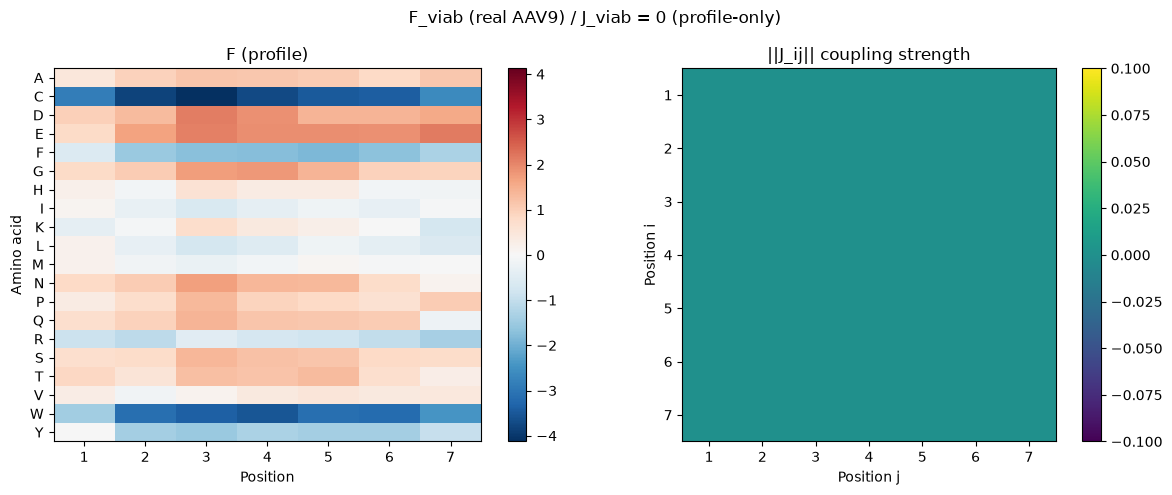

In [24]:
F_viab      = load_F_viab_aav9_mlp()
J_viab_real = load_J_viab_aav9_mlp()
J_viab      = jnp.zeros_like(J_viab_real)  # <-- the only change vs. the sibling notebook

anticorrelation = 0.2
F_sel_anti, J_sel_anti_real = initialize_anticorrelated_weights(
    jax.random.key(10), F_viab, J_viab_real, anticorrelation
)
J_sel_anti = jnp.zeros_like(J_sel_anti_real)  # <-- same here

print(f"max|J_viab| = {float(jnp.abs(J_viab).max())}   max|J_sel_anti| = {float(jnp.abs(J_sel_anti).max())}")
_ = plot_teacher_weights(F_viab, J_viab, title="F_viab (real AAV9) / J_viab = 0 (profile-only)")
plt.show()

## 2. Simulate the assay with the same protocol, `J = 0`

Same `ProtocolV3` construction, same `N=20,000` uniformly random sequences (same seed as the
sibling notebook, so the sequence pool is identical -- only the underlying F/J landscape
differs), same `T_viab=T_sel=1`, `noise_viab=noise_sel=0.5`, `dilution_factor=10`.
`compute_score` sums `F[seq[p], p]` plus the (now identically zero) pairwise term, so
`lambda2`/`lambda3` -- and therefore `target1`/`target2` -- are driven by `F` alone.

In [25]:
key = jax.random.key(0)
key, k_seq = jax.random.split(key)

N = 20_000
sequences = jax.random.randint(k_seq, shape=(N, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)

protocol_profile = ProtocolV3(N0=1_000_000_000, N1=500_000_000,
        dilution_factor=10, sequences=sequences, D=1e9,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel_anti, J_sel=J_sel_anti,
        noise_viab=0.5, noise_sel=0.5, T_sel=1, T_viab=1,
        )

In [26]:
rounds = protocol_profile.N_loop_DE(1)
bio_row, ngs_row = rounds[0]
lambda0, lambda1, lambda2, lambda3, lambda4 = bio_row
lambda0p, lambda2p, lambda3p = ngs_row

lambda0p = np.asarray(lambda0p)
lambda2p = np.asarray(lambda2p)
lambda3p = np.asarray(lambda3p)

eps = 1.0  # pseudocount, same convention as the sibling notebooks

log_enr_viab = np.log((lambda2p + eps) / (lambda0p + eps))  # target1 -- viability
log_enr_sel  = np.log((lambda3p + eps) / (lambda2p + eps))  # target2 -- selectivity

print(f"log_enr_viab: min={log_enr_viab.min():.2f}  max={log_enr_viab.max():.2f}  mean={log_enr_viab.mean():.2f}")
print(f"log_enr_sel : min={log_enr_sel.min():.2f}  max={log_enr_sel.max():.2f}  mean={log_enr_sel.mean():.2f}")

Directed evolution rounds:   0%|          | 0/1 [00:00<?, ?it/s]

Directed evolution rounds: 100%|██████████| 1/1 [00:01<00:00,  1.24s/it]


log_enr_viab: min=-11.66  max=5.81  mean=-4.24
log_enr_sel : min=-13.48  max=10.05  mean=-2.07


In [27]:
def dataset_filename(protocol, label):
    def fmt(v):
        return f"{float(v):g}".replace(".", "")

    if protocol.noise_viab == protocol.noise_sel:
        noise_part = f"noise{fmt(protocol.noise_viab)}"
    else:
        noise_part = f"noiseviab{fmt(protocol.noise_viab)}_noisesel{fmt(protocol.noise_sel)}"

    return (f"diversity{protocol.d0}_Tsel{fmt(protocol._T_sel)}"
            f"_Tviab{fmt(protocol._T_viab)}_{noise_part}_{label}.csv")


def build_or_load_dataset(protocol, sequences, log_enr_viab, log_enr_sel, label):
    """Same recipe as the sibling notebooks -- `label` keeps this ablation's CSVs
    (`profile_only` / `profile_only_bg`) from colliding with the correlated/anticorrelated/
    independent ones, which share the same diversity/T_sel/T_viab/noise parameters."""
    path = dataset_filename(protocol, label)
    if os.path.exists(path):
        print(f"{path} already exists -- loading from disk")
        return pd.read_csv(path)

    seq_strings = ["".join(AA_LABELS[a] for a in row) for row in np.asarray(sequences)]
    df = pd.DataFrame({"sequence": seq_strings, "target1": log_enr_viab, "target2": log_enr_sel})
    df.to_csv(path, index=False)
    print(f"saved {path} ({len(df)} rows)")
    return df


dataset_profile = build_or_load_dataset(protocol_profile, sequences, log_enr_viab, log_enr_sel, label="profile_only")
dataset_profile.head()

diversity20000_Tsel1_Tviab1_noise05_profile_only.csv already exists -- loading from disk


,sequence,target1,target2
0,DDTSNIP,1.987014,-10.750692
1,MSTDFNG,0.188440,-1.424823
2,CQNSWCF,-10.700905,0.693147
3,CRCHSEA,-8.364847,4.888981
4,QAFNMTQ,-3.101790,1.854558


## 3. Train ProfileMLP on `target1`/`target2`

In [28]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


@nnx.jit
def predict_log_enrichment(model, x):
    return model(x, train=False)


### ------------ Sequence string -> raw indices -> one-hot ------------ ###
lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes  = np.frombuffer("".join(dataset_profile["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(dataset_profile), NUM_POSITIONS)
seq_oh     = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[seq_matrix].reshape(len(dataset_profile), -1)

y_viab_all = dataset_profile["target1"].to_numpy()
y_sel_all  = dataset_profile["target2"].to_numpy()

idx_train, idx_test = train_test_split(np.arange(len(dataset_profile)), test_size=0.5, random_state=0)
X_train_full, X_test = seq_oh[idx_train], seq_oh[idx_test]

print(f"X_train_full shape: {X_train_full.shape}  X_test shape: {X_test.shape}")

X_train_full shape: (10000, 140)  X_test shape: (10000, 140)


In [ ]:
y_viab_train, y_viab_test = y_viab_all[idx_train], y_viab_all[idx_test]
Xtr_viab, ytr_viab, Xva_viab, yva_viab = split_train_val(X_train_full, y_viab_train, val_frac=0.15, seed=0)
print(f"ProfileMLP (viab) -- train: {len(Xtr_viab):,}  val: {len(Xva_viab):,}  test: {len(X_test):,}")

model_viab, hist_viab = train_profile_mlp(Xtr_viab, ytr_viab, Xva_viab, yva_viab, seed=0)

ProfileMLP (viab) -- train: 8,500  val: 1,500  test: 10,000


Training ProfileMLP:   0%|          | 0/300 [00:00<?, ?it/s]Exception ignored in: <function _xla_gc_callback at 0xe98dec0b6980>
Traceback (most recent call last):
  File "/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/jax/_src/lib/__init__.py", line 125, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 
Training ProfileMLP:  29%|██▊       | 86/300 [00:12<00:47,  4.48it/s]

In [ ]:
y_sel_train, y_sel_test = y_sel_all[idx_train], y_sel_all[idx_test]
Xtr_sel, ytr_sel, Xva_sel, yva_sel = split_train_val(X_train_full, y_sel_train, val_frac=0.15, seed=1)
print(f"ProfileMLP (sel) -- train: {len(Xtr_sel):,}  val: {len(Xva_sel):,}  test: {len(X_test):,}")

model_sel, hist_sel = train_profile_mlp(Xtr_sel, ytr_sel, Xva_sel, yva_sel, seed=1)

ProfileMLP (sel) -- train: 8,500  val: 1,500  test: 10,000


Training ProfileMLP:  25%|██▌       | 75/300 [00:01<00:04, 47.54it/s]

Early stopping at epoch 75 (best val MSE=0.6518)


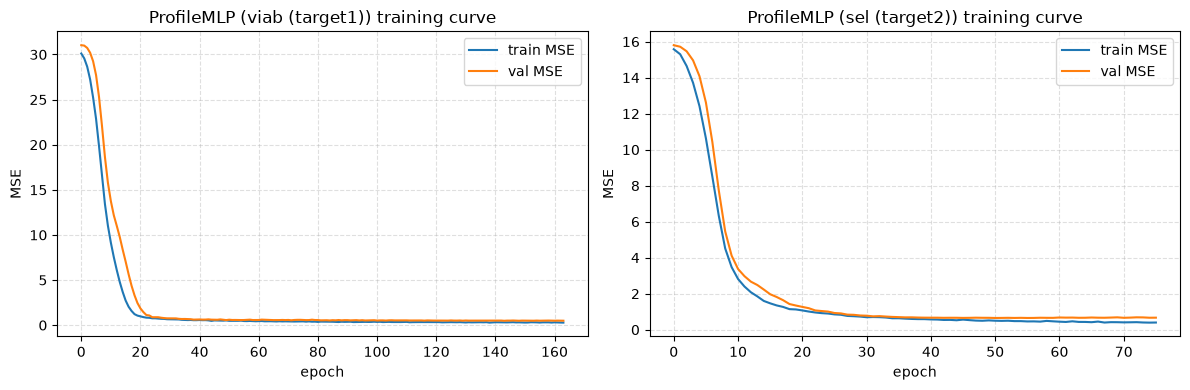

target1 (viab) -- Pearson r (test): 0.9808
target2 (sel)  -- Pearson r (test): 0.9686


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, name in [(axes[0], hist_viab, "viab (target1)"), (axes[1], hist_sel, "sel (target2)")]:
    ax.plot(hist["train_loss"], label="train MSE")
    ax.plot(hist["val_loss"],   label="val MSE")
    ax.set_xlabel("epoch"); ax.set_ylabel("MSE")
    ax.set_title(f"ProfileMLP ({name}) training curve")
    ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

pred_viab_test = np.asarray(predict_log_enrichment(model_viab, jnp.asarray(X_test)))
pred_sel_test  = np.asarray(predict_log_enrichment(model_sel,  jnp.asarray(X_test)))

print(f"target1 (viab) -- Pearson r (test): {pearson(y_viab_test, pred_viab_test):.4f}")
print(f"target2 (sel)  -- Pearson r (test): {pearson(y_sel_test,  pred_sel_test):.4f}")

<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
<b>GLOBAL/THEORETICAL top-K_BEST</b> (K_BEST=50, set in the code cell below): <code>brute_force_top_k</code> exhaustively scores ALL 20^7 &asymp; 1.28 billion possible synthetic 7-mers -- using the REAL AAV9 <code>F_viab</code> profile with <code>J_viab</code> forced to all-zero, and the SYNTHETIC anticorrelated <code>F_sel_anti</code> (anticorrelation=0.2, same as the anticorrelated sibling notebook) with <code>J_sel_anti</code> also forced to all-zero. Because this is a <b>purely additive (profile-only) ablation</b>, the cell below proves the brute-force top-1 is IDENTICAL to the naive greedy per-position argmax of F alone -- there is no hidden epistatic combination to discover here, unlike the anticorrelated sibling notebook's top-50 (real nonzero <code>J_viab</code>, strong sign epistasis). Never observed in any real experiment; do not confuse with the real, measured aav9.csv top-500.
</div>

## 4. Do the TRUE global-optimum variants get recognized by the MLP?

Same exhaustive brute-force scan as the sibling notebook (`compute_score_array` /
`_score_chunk` / `brute_force_top_k`) over the full `20**7` sequence space, now using the
zeroed `J_viab`/`J_sel_anti`. Sanity check included: with `J=0` the brute-force top-1 MUST
equal the naive per-position argmax of `F` alone, since there is no coupling for a joint
combination to gain over independently picking each position's best amino acid.

In [ ]:
def compute_score_array(seq, F, J, L=NUM_POSITIONS):
    """Same formula as Protocol.compute_score, decoupled from a Protocol instance so it can
    be applied to an arbitrary (n, L) array of raw-index sequences."""
    scores = jnp.sum(F[seq, jnp.arange(L)], axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            scores = scores + J[i, j, seq[:, i], seq[:, j]]
    return scores


@jax.jit
def _score_chunk(idx, F, J, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    tmp = idx
    digits = []
    for _ in range(L):
        digits.append(tmp % A)
        tmp = tmp // A
    seq = jnp.stack(digits[::-1], axis=1).astype(jnp.int32)
    return seq, compute_score_array(seq, F, J, L)


def brute_force_top_k(F, J, k=50, chunk_size=20_000_000, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    """Exhaustively scores EVERY possible sequence (A**L of them) against the ground-truth F/J
    and keeps a running top-k, in chunks (so the full A**L x L array of sequences is never
    materialized at once)."""
    total = A ** L
    best_scores = jnp.full((k,), -jnp.inf)
    best_seqs   = jnp.zeros((k, L), dtype=jnp.int32)

    for start in tqdm(range(0, total, chunk_size), desc="brute-force scan"):
        end = min(start + chunk_size, total)
        idx = jnp.arange(start, end)
        seq_chunk, scores_chunk = _score_chunk(idx, F, J)

        kk = min(k, scores_chunk.shape[0])
        local_vals, local_idx = jax.lax.top_k(scores_chunk, kk)
        local_seqs = seq_chunk[local_idx]

        cand_scores = jnp.concatenate([best_scores, local_vals])
        cand_seqs   = jnp.concatenate([best_seqs, local_seqs], axis=0)
        best_scores, merge_idx = jax.lax.top_k(cand_scores, k)
        best_seqs = cand_seqs[merge_idx]

    return np.asarray(best_seqs), np.asarray(best_scores)


K_BEST = 50
best_seqs_viab, best_scores_viab = brute_force_top_k(F_viab, J_viab, k=K_BEST)
best_seqs_sel,  best_scores_sel  = brute_force_top_k(F_sel_anti, J_sel_anti, k=K_BEST)

greedy_viab = [int(jnp.argmax(F_viab[:, p]))    for p in range(NUM_POSITIONS)]
greedy_sel  = [int(jnp.argmax(F_sel_anti[:, p])) for p in range(NUM_POSITIONS)]
print(f"greedy(F_viab)     == brute-force top-1? {greedy_viab == list(best_seqs_viab[0])}")
print(f"greedy(F_sel_anti) == brute-force top-1? {greedy_sel == list(best_seqs_sel[0])}")

print(f"TRUE global-optimum viability score: {best_scores_viab[0]:.2f}")
print(f"TRUE global-optimum selectivity score: {best_scores_sel[0]:.2f}")

brute-force scan: 100%|██████████| 64/64 [00:01<00:00, 36.71it/s]


greedy(F_viab)     == brute-force top-1? True
greedy(F_sel_anti) == brute-force top-1? True
TRUE global-optimum viability score: 12.61
TRUE global-optimum selectivity score: 17.40


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Reuses the same TRUE top-50 (J=0) global-optimum population from directly above (<code>best_seqs_viab</code>/<code>best_seqs_sel</code>) -- just checking how many of those 50 sequences land in the small 20,000-sequence training pool (<code>dataset_profile</code>). Answer is 0 for both, confirming rarity in sequence space is a property of the space itself, independent of whether the landscape has epistasis.
</div>

## 5. Are the TRUE top-50 in the training pool? (should still be ~0 -- rarity is independent of landscape shape)

In [ ]:
def seqs_to_strings(seq_array):
    return ["".join(AA_LABELS[a] for a in row) for row in np.asarray(seq_array)]

best_viab_strings = seqs_to_strings(best_seqs_viab)
best_sel_strings  = seqs_to_strings(best_seqs_sel)

sampled_set  = set(dataset_profile["sequence"])
n_viab_found = sum(s in sampled_set for s in best_viab_strings)
n_sel_found  = sum(s in sampled_set for s in best_sel_strings)

print(f"Of the top-{K_BEST} TRUE-best viability variants, {n_viab_found} appear in the "
      f"{len(dataset_profile):,}-sequence sampled pool")
print(f"Of the top-{K_BEST} TRUE-best selectivity variants, {n_sel_found} appear in the "
      f"{len(dataset_profile):,}-sequence sampled pool")

Of the top-50 TRUE-best viability variants, 0 appear in the 20,000-sequence sampled pool
Of the top-50 TRUE-best selectivity variants, 0 appear in the 20,000-sequence sampled pool


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
A NEW, fully <b>synthetic random background pool of N_BG=200,000</b> uniformly-random 7-mers (<code>sequences_bg</code> / <code>dataset_profile_bg</code>), generated fresh and never used in training, run through the same J=0 protocol. It's used purely as a percentile/z-scoring baseline for the TRUE top-50 population from section 4 above -- <i>not</i> a top-anything itself. Note this pool is deliberately smaller than the anticorrelated sibling notebook's equivalent background pool (2,000,000) -- per the markdown above, 200,000 already gives ~0.02% percentile resolution, more than enough to place a top-50.
</div>

## 6. Does the MLP now recognize the TRUE top-50 as exceptional?

Same percentile analysis as the sibling notebook, against a background pool of 200,000
FRESH random sequences (never used in training) run through the SAME `J=0` protocol --
smaller than the sibling notebook's 2,000,000 (percentile resolution to ~0.02%, more than
enough to place a top-50) to keep this ablation notebook fast.

In [ ]:
key2 = jax.random.key(42)
key2, k_seq2 = jax.random.split(key2)

N_BG = 200_000
sequences_bg = jax.random.randint(k_seq2, shape=(N_BG, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)

protocol_profile_bg = ProtocolV3(N0=1_000_000_000, N1=500_000_000,
        dilution_factor=10, sequences=sequences_bg, D=1e9,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel_anti, J_sel=J_sel_anti,
        noise_viab=0.5, noise_sel=0.5, T_sel=1, T_viab=1,
        )

rounds_bg = protocol_profile_bg.N_loop_DE(1)
_, ngs_row_bg = rounds_bg[0]
lambda0p_bg, lambda2p_bg, lambda3p_bg = (np.asarray(a) for a in ngs_row_bg)

log_enr_viab_bg = np.log((lambda2p_bg + eps) / (lambda0p_bg + eps))
log_enr_sel_bg  = np.log((lambda3p_bg + eps) / (lambda2p_bg + eps))

dataset_profile_bg = build_or_load_dataset(
    protocol_profile_bg, sequences_bg, log_enr_viab_bg, log_enr_sel_bg, label="profile_only_bg"
)

seq_bytes_bg  = np.frombuffer("".join(dataset_profile_bg["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix_bg = lut[seq_bytes_bg].reshape(len(dataset_profile_bg), NUM_POSITIONS)
X_bg          = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[seq_matrix_bg].reshape(len(dataset_profile_bg), -1)

pred_viab_bg = np.asarray(predict_log_enrichment(model_viab, jnp.asarray(X_bg)))
pred_sel_bg  = np.asarray(predict_log_enrichment(model_sel,  jnp.asarray(X_bg)))

viab_scores_bg = np.asarray(compute_score_array(jnp.asarray(seq_matrix_bg), F_viab, J_viab))
sel_scores_bg  = np.asarray(compute_score_array(jnp.asarray(seq_matrix_bg), F_sel_anti, J_sel_anti))

print(f"TRUE global optimum viability: {best_scores_viab[0]:.2f}  (best of {N_BG:,} random: {viab_scores_bg.max():.2f})")
print(f"TRUE global optimum selectivity: {best_scores_sel[0]:.2f}  (best of {N_BG:,} random: {sel_scores_bg.max():.2f})")

Directed evolution rounds: 100%|██████████| 1/1 [00:06<00:00,  6.01s/it]


saved diversity200000_Tsel1_Tviab1_noise05_profile_only_bg.csv (200000 rows)
TRUE global optimum viability: 12.61  (best of 200,000 random: 11.16)
TRUE global optimum selectivity: 17.40  (best of 200,000 random: 14.91)


MLP-predicted score for the TRUE #1 viability variant: 6.63  -> 100.0th percentile of the 200,000-sample predicted-score distribution
MLP-predicted score for the TRUE #1 selectivity variant: 12.06  -> 100.0th percentile of the 200,000-sample predicted-score distribution
Median percentile across all top-50 TRUE-best viability variants: 100.0
Median percentile across all top-50 TRUE-best selectivity variants: 100.0


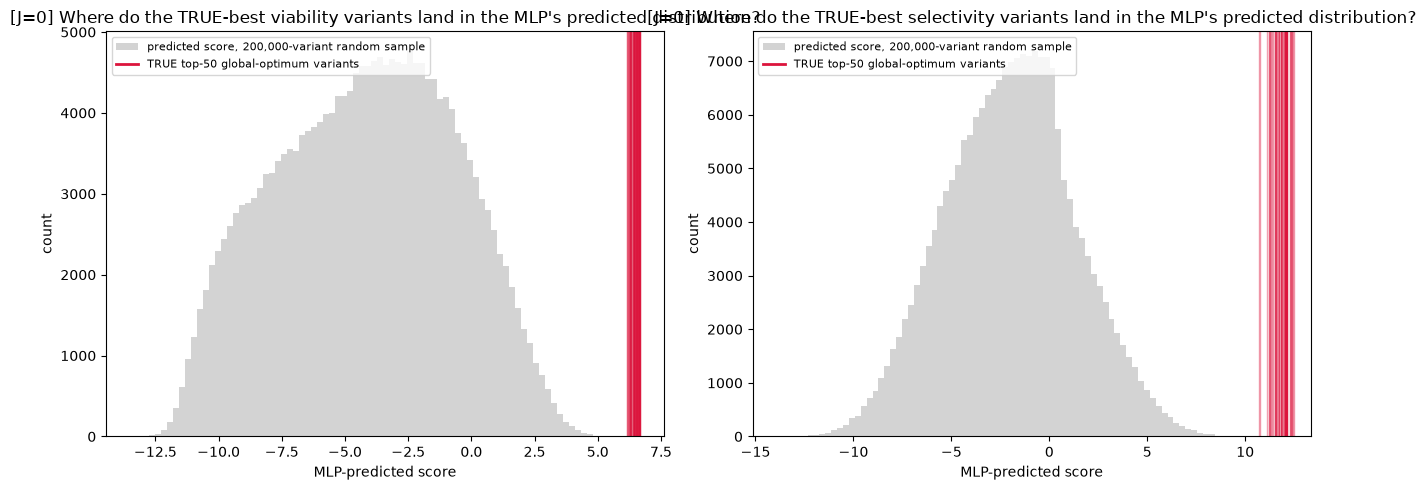

In [ ]:
X_best_viab = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[best_seqs_viab].reshape(K_BEST, -1)
X_best_sel  = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[best_seqs_sel].reshape(K_BEST, -1)

pred_best_viab = np.asarray(predict_log_enrichment(model_viab, jnp.asarray(X_best_viab)))
pred_best_sel  = np.asarray(predict_log_enrichment(model_sel,  jnp.asarray(X_best_sel)))

pct_viab = [100 * (pred_viab_bg < v).mean() for v in pred_best_viab]
pct_sel  = [100 * (pred_sel_bg  < v).mean() for v in pred_best_sel]

print(f"MLP-predicted log enrichment for the TRUE #1 viability variant: {pred_best_viab[0]:.2f}  "
      f"-> {pct_viab[0]:.1f}th percentile of the {N_BG:,}-sample predicted-log-enrichment distribution")
print(f"MLP-predicted log enrichment for the TRUE #1 selectivity variant: {pred_best_sel[0]:.2f}  "
      f"-> {pct_sel[0]:.1f}th percentile of the {N_BG:,}-sample predicted-log-enrichment distribution")
print(f"Median percentile across all top-{K_BEST} TRUE-best viability variants: {np.median(pct_viab):.1f}")
print(f"Median percentile across all top-{K_BEST} TRUE-best selectivity variants: {np.median(pct_sel):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred_pop, pred_best, name in [(axes[0], pred_viab_bg, pred_best_viab, "viability"),
                                       (axes[1], pred_sel_bg,  pred_best_sel,  "selectivity")]:
    ax.hist(pred_pop, bins=80, color="lightgray",
            label=f"predicted log enrichment, {len(pred_pop):,}-variant random sample")
    for v in pred_best:
        ax.axvline(v, color="crimson", alpha=0.4, lw=1)
    ax.axvline(pred_best[0], color="crimson", lw=2, label=f"TRUE top-{K_BEST} global-optimum variants")
    ax.set_xlabel("MLP-predicted log enrichment")
    ax.set_ylabel("count")
    ax.set_title(f"[J=0] Where do the TRUE-best {name} variants land in the MLP's predicted distribution?")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

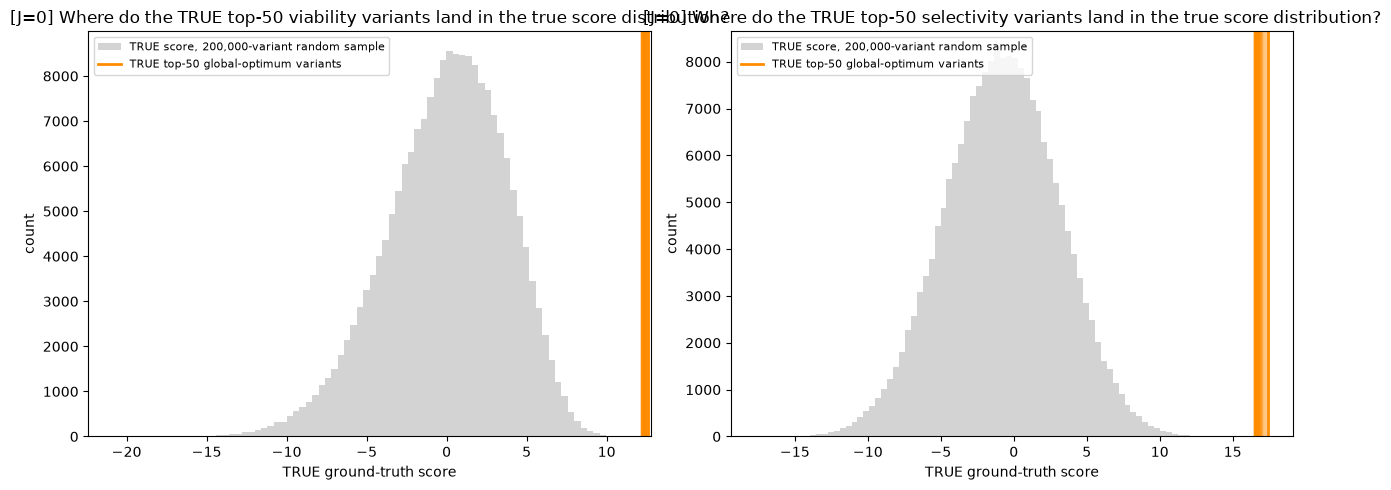

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, true_pop, true_best, name in [(axes[0], viab_scores_bg, best_scores_viab, "viability"),
                                       (axes[1], sel_scores_bg,  best_scores_sel,  "selectivity")]:
    ax.hist(true_pop, bins=80, color="lightgray",
            label=f"TRUE score, {len(true_pop):,}-variant random sample")
    for v in true_best:
        ax.axvline(v, color="darkorange", alpha=0.4, lw=1)
    ax.axvline(true_best[0], color="darkorange", lw=2, label=f"TRUE top-{K_BEST} global-optimum variants")
    ax.set_xlabel("TRUE ground-truth score")
    ax.set_ylabel("count")
    ax.set_title(f"[J=0] Where do the TRUE top-{K_BEST} {name} variants land in the true score distribution?")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Conclusion

**Fill in after running.** Compare the median percentiles above to the sibling notebook's
(`MLP_for_anticorrelated_weights.ipynb`, real `J`): viability 18.3th / selectivity 100.0th.

- If both jump to ~100th here, that confirms the diagnosis: the earlier viability failure
  was caused specifically by sign epistasis in the real `J_viab`, not by sample size, model
  capacity, or the training procedure -- a purely additive profile is exactly the kind of
  smooth function this MLP/random-sampling setup CAN learn to extrapolate correctly.
- If viability is still poorly predicted even at `J=0`, the profile `F_viab` itself (not
  the coupling) is the harder part to learn, and the earlier diagnosis needs revisiting.